# MODELOS PREDICTIVOS DE APRENDIZAJE SUPERVISADO
# REGRESIÓN

In [1]:
import pandas as pd
X_train_mod= pd.read_csv("X_train_mod.csv")
X_test_mod= pd.read_csv("X_test_mod.csv")
y_reg= pd.read_csv("y_reg.csv")

In [2]:
X_train_mod.head(10)

,log_num__review_count,log_num__n_reviews,log_num__sum_useful,log_num__n_checkins,num__latitude,num__longitude,num__cat_Nightlife,num__cat_Sandwiches,num__cat_Bars,num__cat_American_Traditional,...,cat__review_days_group_trayectoria_baja,cat__review_days_group_trayectoria_media_alta,cat__review_days_group_trayectoria_media_baja,cluster,business_id,mean_sentiment,std_sentiment,positive_ratio,negative_ratio,topic_name
0,-0.336006,-1.345111,-1.117791,0.503743,0.541966,0.931880,-0.462435,-0.453775,-0.536567,-0.445758,...,1.0,0.0,0.0,1,ostgbmaf36hOicxyl71sPg,-0.086435,NaN,0.000000,0.000000,Servicio y atención
1,0.364131,1.645757,1.089416,0.098361,0.339491,-0.188339,2.162465,2.203736,1.863700,-0.445758,...,0.0,0.0,0.0,2,hfIr80hSKHko4RDXdrBEKg,0.278962,0.214544,0.785714,0.047619,Comida (platos específicos)
2,-0.742948,-1.345111,-1.117791,-1.392658,-1.453650,0.369969,-0.462435,-0.453775,-0.536567,-0.445758,...,1.0,0.0,0.0,1,sMrUg8UgpvsV0qEzVScGpw,-0.175000,NaN,0.000000,1.000000,Servicio y atención
3,0.086098,0.316749,0.088674,0.010449,0.561174,0.936556,-0.462435,-0.453775,1.863700,-0.445758,...,0.0,0.0,0.0,2,eHwwt8JeBsHPubOg2qtJeQ,0.317836,0.172902,0.900000,0.000000,Comida y precio
4,1.304090,-0.451872,0.744942,1.073276,0.574498,0.920624,-0.462435,-0.453775,-0.536567,2.243368,...,0.0,0.0,1.0,3,-hsR1sWeD9Vw_nh5Qym2fg,0.363631,0.072899,1.000000,0.000000,Servicio y atención
5,-0.486662,1.192101,1.295139,-0.645112,-0.770516,-1.711983,2.162465,-0.453775,1.863700,-0.445758,...,0.0,0.0,0.0,2,QCRLjou6Q_jclARDz0ss5A,0.404970,0.216173,0.923077,0.000000,Experiencia general
6,1.163465,0.619101,0.440998,0.858616,-1.161545,-0.176494,-0.462435,-0.453775,-0.536567,2.243368,...,0.0,0.0,1.0,3,SYCGlb0WFyyVxD2K9Z-YuA,0.272985,0.229905,0.857143,0.071429,Comida y precio
7,-0.151619,-0.451872,-0.598195,0.000902,0.493757,-2.357138,-0.462435,-0.453775,-0.536567,-0.445758,...,0.0,0.0,1.0,3,g6kAgbQQSQ8i1A_Za-znJQ,0.058830,0.221387,0.500000,0.250000,Servicio y atención
8,-1.116431,-0.949847,-1.117791,0.189176,-1.163426,-0.167955,-0.462435,-0.453775,-0.536567,-0.445758,...,0.0,0.0,1.0,3,Sn6jSXKN4OD42rCkS2kiww,0.517879,0.210418,1.000000,0.000000,Calidad de la comida
9,1.881566,1.903263,1.006039,1.443894,-1.538483,0.361935,2.162465,-0.453775,1.863700,2.243368,...,0.0,0.0,0.0,2,ZbjlLNcnTpemOsqX96692w,0.260595,0.251078,0.727273,0.072727,Experiencia general


In [3]:
# Convertir topic_name a dummies
topic_train = pd.get_dummies(X_train_mod["topic_name"], prefix="topic")
topic_test = pd.get_dummies(X_test_mod["topic_name"], prefix="topic")

topic_train, topic_test = topic_train.align(topic_test, join="outer", axis=1, fill_value=0)

X_train_mod = pd.concat([X_train_mod, topic_train], axis=1)
X_test_mod = pd.concat([X_test_mod, topic_test], axis=1)

In [4]:
#VARIABLES EXPLICATIVAS

# Selección de variables
vars_cluster = ["cluster"]

vars_categorias = [col for col in X_train_mod.columns if col.startswith("num__cat_")]

vars_sentimiento = ["mean_sentiment", "std_sentiment", "positive_ratio", "negative_ratio"]

vars_temas = [col for col in X_train_mod.columns if col.startswith("topic_")]

features_selected = vars_cluster + vars_categorias + vars_sentimiento + vars_temas
features_selected = list(dict.fromkeys(features_selected))

# Conjuntos X
X_train_REG = X_train_mod[features_selected].copy()
X_test_REG = X_test_mod[features_selected].copy()

# Variable respuesta
y_map = y_reg.set_index("business_id")["avg_review_stars"]
y_train_REG = X_train_mod["business_id"].map(y_map)
y_test_REG = X_test_mod["business_id"].map(y_map)


In [5]:
#Corregir topic
X_train_REG = X_train_REG.drop(columns=["topic_name"])
X_test_REG = X_test_REG.drop(columns=["topic_name"])

In [6]:
#Corregir booleanas
bool_cols = X_train_REG.select_dtypes(include="bool").columns

X_train_REG[bool_cols] = X_train_REG[bool_cols].astype(int)
X_test_REG[bool_cols] = X_test_REG[bool_cols].astype(int)

In [7]:
#COMPROBAR
X_train_REG.dtypes

cluster                                int64
num__cat_Nightlife                   float64
num__cat_Sandwiches                  float64
num__cat_Bars                        float64
num__cat_American_Traditional        float64
num__cat_Fast_Food                   float64
num__cat_Pizza                       float64
num__cat_Breakfast_&_Brunch          float64
num__cat_Burgers                     float64
num__cat_American_New                float64
num__cat_Mexican                     float64
num__cat_Italian                     float64
num__cat_Coffee_&_Tea                float64
num__cat_Seafood                     float64
num__cat_Salad                       float64
mean_sentiment                       float64
std_sentiment                        float64
positive_ratio                       float64
negative_ratio                       float64
topic_Calidad de la comida             int64
topic_Comida (platos específicos)      int64
topic_Comida y precio                  int64
topic_Expe

In [8]:
y_train_REG.dtypes

dtype('float64')

In [9]:
#GUARDAR POR REPRODUCIBILIDAD
X_train_REG.to_csv("X_train_REG.csv", index=False)
X_test_REG.to_csv("X_test_REG.csv", index=False)

y_train_REG.to_csv("y_train_REG.csv", index=False)
y_test_REG.to_csv("y_test_REG.csv", index=False)

In [10]:
import pandas as pd

X_train_REG = pd.read_csv("X_train_REG.csv")
X_test_REG = pd.read_csv("X_test_REG.csv")

y_train_REG = pd.read_csv("y_train_REG.csv").squeeze()
y_test_REG = pd.read_csv("y_test_REG.csv").squeeze()

In [11]:
#MODELO BASE RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

In [ ]:
#GRID DE LOS PARÁMETROS A OPTIMIZAR
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
}

In [13]:
#CROSS VALIDATION: GRID SEARCH
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross validation
    scoring="r2",            # métrica principal
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_REG, y_train_REG)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [17]:
#MEJORES PARÁMETROS
print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

Mejores parámetros: {'max_depth': 10, 'n_estimators': 200}
Mejor score CV: 0.7347215890218317


In [15]:
#MODELO FINAL OPTIMIZADO
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test_REG)

In [19]:
#EVALUACIÓN EN TEST
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

y_pred = grid.best_estimator_.predict(X_test_REG)

print("R2 test:", r2_score(y_test_REG, y_pred))
print("RMSE test:", sqrt(mean_squared_error(y_test_REG, y_pred)))
print("MAE test:", mean_absolute_error(y_test_REG, y_pred))

R2 test: 0.7457938544445442
RMSE test: 0.6169448883008227
MAE test: 0.422082751255364


In [20]:
#IMPORTANCIA DE LAS VARIABLES
import pandas as pd

importances = pd.Series(best_rf.feature_importances_, index=X_train_REG.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

mean_sentiment                       0.801420
positive_ratio                       0.080519
topic_Servicio y atención            0.046710
std_sentiment                        0.028302
num__cat_Fast_Food                   0.004680
negative_ratio                       0.003838
topic_Calidad de la comida           0.003754
num__cat_Burgers                     0.003019
num__cat_Coffee_&_Tea                0.002696
num__cat_Sandwiches                  0.002498
num__cat_Pizza                       0.002433
cluster                              0.002254
topic_Comida (platos específicos)    0.001903
num__cat_Breakfast_&_Brunch          0.001834
num__cat_American_Traditional        0.001785
dtype: float64


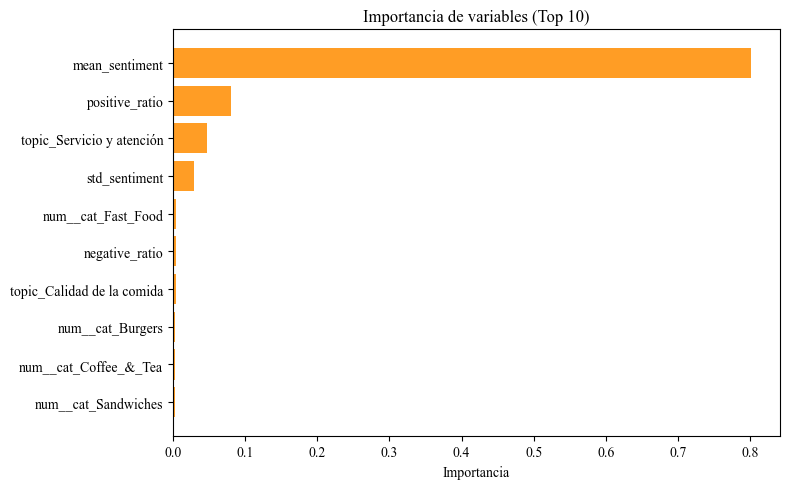

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Fuente
plt.rcParams["font.family"] = "Times New Roman"

# Importancias del modelo
importances = grid.best_estimator_.feature_importances_
features = X_train_REG.columns

# DataFrame ordenado
feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Gráfico (top 10)
plt.figure(figsize=(8,5))
plt.barh(
    feat_imp["feature"][:10][::-1],
    feat_imp["importance"][:10][::-1],
    color="#FF8C00DA"
)

plt.xlabel("Importancia")
plt.title("Importancia de variables (Top 10)")
plt.tight_layout()
plt.show()

## Comportamiento de las predicciones

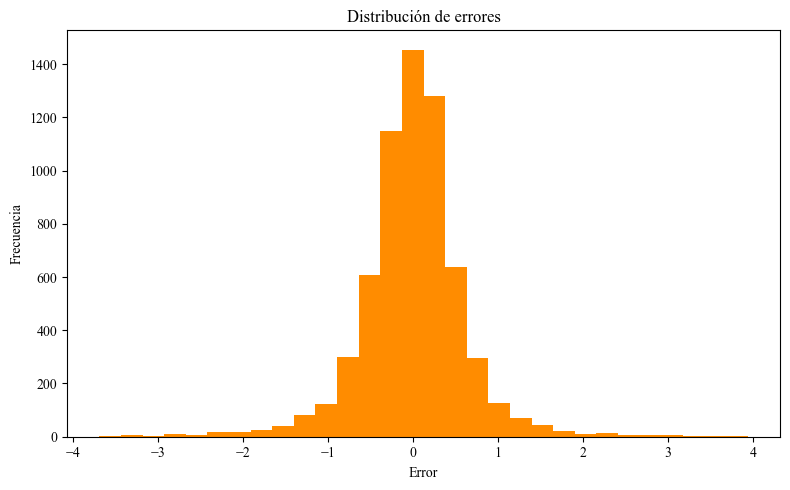

In [27]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

residuos = y_test_REG - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuos, bins=30, color="#FF8C00")
plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

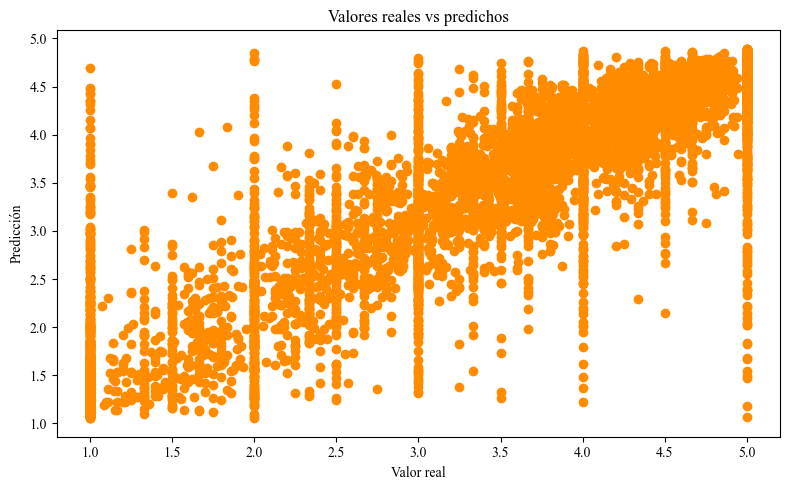

In [28]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(8,5))
plt.scatter(y_test_REG, y_pred, color="#FF8C00")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Valores reales vs predichos")
plt.tight_layout()
plt.show()

# CLASIFICACIÓN

In [31]:
y_clf= pd.read_csv("y_clf.csv")

In [32]:
features_selected_clf = [
    "log_num__review_count",
    "log_num__n_reviews",
    "log_num__sum_useful",
    "log_num__n_checkins",
    "num__review_days",
    "num__open_days_count",
    "num__open_weekend",
    "num__open_7_days",
    "num__first_year",
    "num__last_year",
    "num__trayectoria_trayectoria_baja",
    "num__trayectoria_trayectoria_media_baja",
    "num__trayectoria_trayectoria_media_alta",
    "num__trayectoria_trayectoria_alta"
]

# Conjuntos X
X_train_CLF = X_train_mod[features_selected_clf].copy()
X_test_CLF = X_test_mod[features_selected_clf].copy()

# Variable respuesta
y_map = y_clf.set_index("business_id")["is_open"]
y_train_CLF = X_train_mod["business_id"].map(y_map)
y_test_CLF = X_test_mod["business_id"].map(y_map)

In [33]:
#COMPROBAR
X_train_CLF.dtypes

log_num__review_count                      float64
log_num__n_reviews                         float64
log_num__sum_useful                        float64
log_num__n_checkins                        float64
num__review_days                           float64
num__open_days_count                       float64
num__open_weekend                          float64
num__open_7_days                           float64
num__first_year                            float64
num__last_year                             float64
num__trayectoria_trayectoria_baja          float64
num__trayectoria_trayectoria_media_baja    float64
num__trayectoria_trayectoria_media_alta    float64
num__trayectoria_trayectoria_alta          float64
dtype: object

In [34]:
y_train_CLF.dtype
y_test_CLF.dtype

dtype('int64')

In [35]:
# GUARDAR POR REPRODUCIBILIDAD
X_train_CLF.to_csv("X_train_CLF.csv", index=False)
X_test_CLF.to_csv("X_test_CLF.csv", index=False)

y_train_CLF.to_csv("y_train_CLF.csv", index=False)
y_test_CLF.to_csv("y_test_CLF.csv", index=False)

In [36]:
import pandas as pd

X_train_CLF = pd.read_csv("X_train_CLF.csv")
X_test_CLF = pd.read_csv("X_test_CLF.csv")

y_train_CLF = pd.read_csv("y_train_CLF.csv").squeeze()
y_test_CLF = pd.read_csv("y_test_CLF.csv").squeeze()

In [37]:
#MODELO BASE
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [38]:
#GRID DE PARÁMETROS
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
}

In [39]:
#VALIDACIÓN CRUZADA GRIDSEARCH
from sklearn.model_selection import GridSearchCV

grid_clf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train_CLF, y_train_CLF)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [40]:
#MEJORES PARÁMTEROS
print("Mejores parámetros:", grid_clf.best_params_)
print("Mejor score CV:", grid_clf.best_score_)

Mejores parámetros: {'max_depth': 10, 'n_estimators': 200}
Mejor score CV: 0.9803187818809878


In [41]:
#PREDICCIONES CON TEST
y_pred_clf = grid_clf.best_estimator_.predict(X_test_CLF)

In [42]:
#EVALUAR MODELO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy test:", accuracy_score(y_test_CLF, y_pred_clf))
print("Precision test:", precision_score(y_test_CLF, y_pred_clf))
print("Recall test:", recall_score(y_test_CLF, y_pred_clf))
print("F1 test:", f1_score(y_test_CLF, y_pred_clf))

print("Confusion matrix:")
print(confusion_matrix(y_test_CLF, y_pred_clf))

print(classification_report(y_test_CLF, y_pred_clf))

Accuracy test: 0.9640219952867243
Precision test: 0.9651733417761595
Recall test: 0.9985260399606944
F1 test: 0.9815664493278596
Confusion matrix:
[[  39  220]
 [   9 6097]]
              precision    recall  f1-score   support

           0       0.81      0.15      0.25       259
           1       0.97      1.00      0.98      6106

    accuracy                           0.96      6365
   macro avg       0.89      0.57      0.62      6365
weighted avg       0.96      0.96      0.95      6365



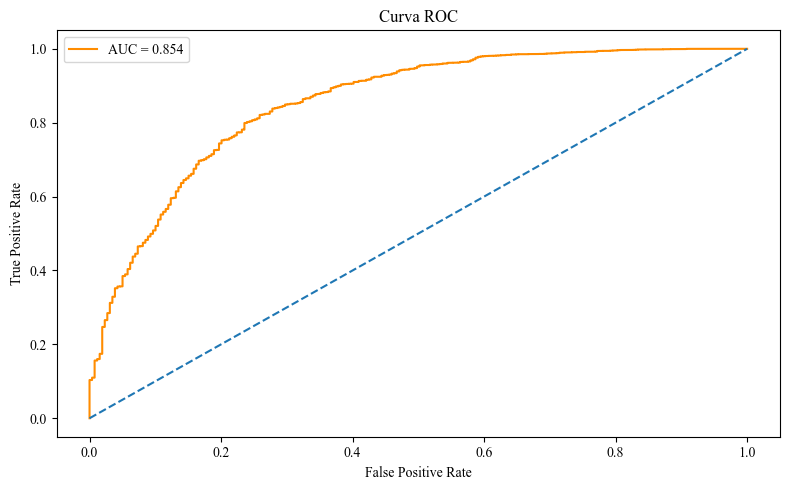

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades (no predicción binaria)
y_prob = grid_clf.best_estimator_.predict_proba(X_test_CLF)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_CLF, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color="#FF8C00", label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # línea base

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
#IMPORTANCIA DE VARIABLES
import pandas as pd

importancias = pd.Series(
    grid_clf.best_estimator_.feature_importances_,
    index=X_train_CLF.columns
).sort_values(ascending=False)

print(importancias)

log_num__review_count                      0.372785
log_num__n_checkins                        0.181349
num__review_days                           0.125936
log_num__n_reviews                         0.105967
log_num__sum_useful                        0.076862
num__trayectoria_trayectoria_baja          0.041749
num__last_year                             0.026279
num__open_days_count                       0.024801
num__trayectoria_trayectoria_alta          0.009881
num__open_weekend                          0.009161
num__open_7_days                           0.008866
num__trayectoria_trayectoria_media_baja    0.007541
num__trayectoria_trayectoria_media_alta    0.007176
num__first_year                            0.001647
dtype: float64


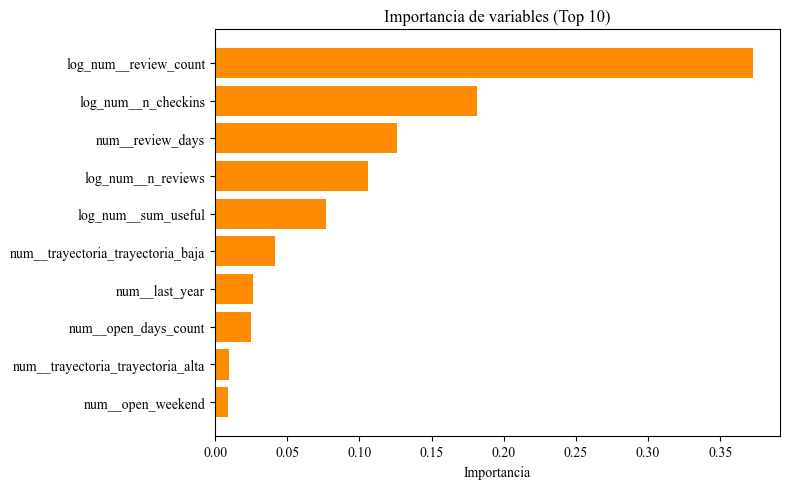

In [44]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(8,5))
plt.barh(importancias.head(10).index[::-1], importancias.head(10).values[::-1], color="#FF8C00")
plt.xlabel("Importancia")
plt.title("Importancia de variables (Top 10)")
plt.tight_layout()
plt.show()